# Group Analysis


> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


In [ ]:
%matplotlib inline
pass
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.stats import regress, zscore
from nltools.data import Brain_Data, Design_Matrix
from nltools.stats import regress
from nltools.external import glover_hrf
from scipy.stats import ttest_1samp

def plot_timeseries(data, linewidth=3, labels=None, axes=True):
    f, a = plt.subplots(figsize=(20, 5))
    a.plot(data, linewidth=linewidth)
    a.set_ylabel('Intensity', fontsize=18)
    a.set_xlabel('Time', fontsize=18)
    plt.tight_layout()
    if labels is not None:
        plt.legend(labels, fontsize=18)
    if not axes:
        a.axes.get_xaxis().set_visible(False)
        a.axes.get_yaxis().set_visible(False)

def simulate_timeseries(n_tr=200, n_trial=5, amplitude=1, tr=1, sigma=0.05):
    y = np.zeros(n_tr)
    y[np.arange(20, n_tr, int(n_tr / n_trial))] = amplitude
    hrf = glover_hrf(tr, oversampling=1)
    y = np.convolve(y, hrf, mode='same')
    epsilon = sigma * np.random.randn(n_tr)
    y = y + epsilon
    return y
sim1 = simulate_timeseries(sigma=0)
sim2 = simulate_timeseries(sigma=0.05)
plot_timeseries(np.vstack([sim1, sim2]).T, labels=['Signal', 'Noisy Signal'])

## Exercises

### 1. Which regions are more involved with visual compared to auditory sensory processing?
 - Create a contrast to test this hypothesis
 - run a group level t-test
 - plot the results
 - write the file to your output folder.

In [ ]:
import bids
from tqdm import tqdm

# set data directory
data_dir = '/home/jovyan/shared/PSYCH60-22S/data/localizer'

# get bids layout for localizer project
layout = bids.BIDSLayout(data_dir + '/derivatives/fmriprep/', config=['bids','derivatives'])

# get subject list and sort it
subList = layout.get(target='subject', return_type='id') # get subject list
subList.sort()
subList

['S01',
 'S02',
 'S03',
 'S04',
 'S05',
 'S06',
 'S07',
 'S08',
 'S09',
 'S10',
 'S11',
 'S12',
 'S13',
 'S14',
 'S15',
 'S16',
 'S17',
 'S18',
 'S19',
 'S20',
 'S21',
 'S22',
 'S23',
 'S24',
 'S25',
 'S26',
 'S27',
 'S28']

In [ ]:
# define file strings
vidString = 'video'
checkString = 'checkerboard'
audString = 'audio'

# loop through each subject
vva = [] # initialize contrast vector
for SUB in tqdm(subList):

    # get beta files
    vid_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{vidString}*nii.gz'))
    check_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{checkString}*nii.gz'))
    aud_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{audString}*nii.gz'))

    # combine video and checkerboard lists
    vList = vid_file_list + check_file_list

    # load visual task betas
    vData = Brain_Data(vList).mean()

    # load auditory task betas
    aData = Brain_Data(aud_file_list).mean()

    # compute subject-level contrast
    vva.append(vData - aData)



100%|██████████| 28/28 [02:54<00:00,  6.25s/it]


In [ ]:
# combine all subject-level contrasts into one Brain_Data object
vva_con = Brain_Data(vva)

# run t-test
stats = vva_con.ttest()

# plot t-stat on brain
stats['t'].iplot()


interactive(children=(FloatText(value=0.0, description='Threshold'), HTML(value='Image is 3D', description='Vo…

### 2. Which regions are more involved in processing numbers compared to words?
 - Create a contrast to test this hypothesis
 - run a group level t-test
 - plot the results
 - write the file to your output folder.

In [ ]:
# define file strings
compString = 'computation'
sentString = 'sentence'

# loop through each subject
cvs = [] # initialize contrast vector
for SUB in tqdm(subList):

    # get beta files
    comp_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{compString}*nii.gz'))
    sent_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{sentString}*nii.gz'))

    # load computation task betas
    cData = Brain_Data(comp_file_list).mean()

    # load sentence task betas
    sData = Brain_Data(sent_file_list).mean()

    # compute subject-level contrastb
    cvs.append(cData - sData)

100%|██████████| 28/28 [01:10<00:00,  2.53s/it]


In [ ]:
# get contrasts in one brain data object
cvs_con = Brain_Data(cvs)

# run t-test
stats = cvs_con.ttest()

# plot
stats['t'].iplot()

interactive(children=(FloatText(value=0.0, description='Threshold'), HTML(value='Image is 3D', description='Vo…

### 3. Are there sex differences?
In this exercise, create a two sample design matrix comparing men and women on arithmetic vs reading.

You will first have to figure out the subjects gender using the using the `participants.tsv` file.

 - Create a contrast to test this hypothesis
 - run a group level t-test
 - plot the results
 - write the file to your output folder.

In [ ]:
### PLAN ###
# split subjects by sex
# within each group, generate arithmetic vs reading contrasts for each subject
# get all contrasts into a single Brain_Data object with dimensions subs x voxels, with one group on top of the other in terms of rows
# make a design matrix according to the Independent-Samples T-Test - Dummy Code setup described above
# add the design matrix to the Brain_Data object and run a GLM
# plot the values for the second beta parameter (the contrast parameter)


In [ ]:
# get BIDS layout and meta-data
from bids import BIDSLayout, BIDSValidator

data_dir = '/home/jovyan/shared/PSYCH60-22S/data/localizer'

layout = BIDSLayout(data_dir, derivatives=False)

meta_data = pd.read_csv(layout.get(suffix='participants', extension='.tsv')[0], sep='\t')

In [ ]:
# examine the meta_data file
meta_data

,participant_id,age,sex,site,family,language
0,S01,24.0,M,SHFJ,F01,French
1,S02,20.0,M,SHFJ,F02,French
2,S03,22.0,F,SHFJ,F03,French
3,S04,20.0,M,Neurospin,F04,French
4,S05,23.0,F,Neurospin,F05,French
...,...,...,...,...,...,...
89,S90,21.0,M,SHFJ,F90,French
90,S91,23.0,M,Neurospin,F91,French
91,S92,26.0,F,SHFJ,F92,French
92,S93,36.0,M,Neurospin,F93,French


In [ ]:
# separate subject ID by sex
fSubs = meta_data.participant_id.loc[meta_data.sex=='F'].tolist()
mSubs = meta_data.participant_id.loc[meta_data.sex=='M'].tolist()

# get female and male subject lists intersected with subList
fSubs = set(fSubs) & set(subList)
mSubs = set(mSubs) & set(subList)

In [ ]:
# loop through females and compute contrasts

compString = 'computation'
sentString = 'sentence'

cvs = []
for SUB in tqdm(fSubs):

    # get beta files
    comp_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{compString}*nii.gz'))
    sent_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{sentString}*nii.gz'))

    # load computation task betas
    cData = Brain_Data(comp_file_list).mean()

    # load sentence task betas
    sData = Brain_Data(sent_file_list).mean()

    # compute subject-level contrastb
    cvs.append(cData - sData)

cvs_f = Brain_Data(cvs)


100%|██████████| 17/17 [00:42<00:00,  2.53s/it]


In [ ]:
# loop through males and compute contrasts

cvs = []
for SUB in tqdm(mSubs):

    # get beta files
    comp_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{compString}*nii.gz'))
    sent_file_list = glob.glob(os.path.join(data_dir, 'derivatives','fmriprep','*', 'func', f'sub-{SUB}*_{sentString}*nii.gz'))

    # load computation task betas
    cData = Brain_Data(comp_file_list).mean()

    # load sentence task betas
    sData = Brain_Data(sent_file_list).mean()

    # compute subject-level contrastb
    cvs.append(cData - sData)

cvs_m = Brain_Data(cvs)

100%|██████████| 11/11 [00:27<00:00,  2.53s/it]


In [ ]:
# combine betas from each group into single Brain_Data object
conData = Brain_Data([cvs_f, cvs_m])
conData

nltools.data.brain_data.Brain_Data(data=(28, 238955), Y=0, X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz, output_file=[])

<AxesSubplot:>

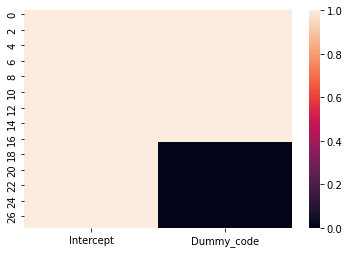

In [ ]:
# create design matrix
conData.X = pd.DataFrame({'Intercept':np.ones(len(fSubs) + len(mSubs)), 'Dummy_code':np.concatenate([np.ones(len(fSubs)),np.zeros(len(mSubs))])})
sns.heatmap(conData.X)

In [ ]:
# run the glm
conData_stats = conData.regress()

# plot the t-values
conData_stats['t'][1].iplot()

interactive(children=(FloatText(value=0.0, description='Threshold'), HTML(value='Image is 3D', description='Vo…